# Task 1 — Dataset Understanding & Exploratory Analysis
**COMP41840 AI for Health**  
**Owner:** Sergio  
**Dataset:** Multi-Modal Breast Cancer Dataset (780 patients)


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style='whitegrid')

DATA_ROOT = Path('../data/raw')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)

_SRC = Path('../src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))
from patient_split import kaggle_multimodal_available, build_aligned_manifest

USE_ALIGNED = kaggle_multimodal_available(DATA_ROOT)
CLASSES = ['benign', 'malignant', 'normal']


def iter_class_images(data_root: Path, cls: str):
    paths = []
    d = data_root / cls / 'images'
    if d.exists():
        paths.extend(sorted(d.glob('*.png')))
    for sub in sorted((data_root / 'dataset').glob(f'dataset*/{cls}/images')):
        paths.extend(sorted(sub.glob('*.png')))
    return paths


def first_class_image(data_root: Path, cls: str):
    paths = iter_class_images(data_root, cls)
    return paths[0] if paths else None

## 1.1 — Image Dataset Structure

benign: 437 images
malignant: 210 images
normal: 133 images


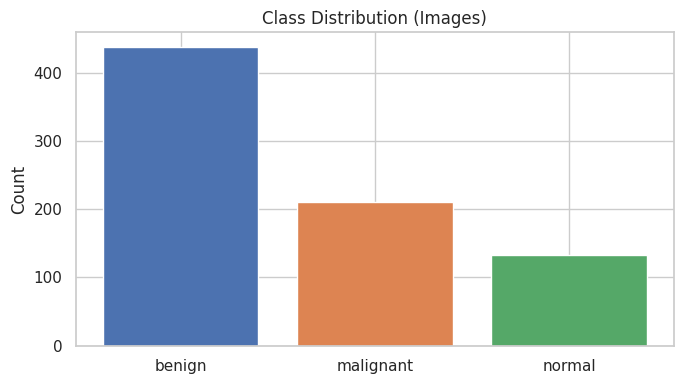

In [11]:
# Count images per class (flat or nested Kaggle layout)
counts = {cls: len(iter_class_images(DATA_ROOT, cls)) for cls in CLASSES}
for cls, n in counts.items():
    print(f'{cls}: {n} images')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.keys(), counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Class Distribution (Images)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/class_distribution.png', dpi=150)
plt.show()

## 1.2 — Image Resolution & Format

In [12]:
widths, heights, class_labels = [], [], []
for cls in CLASSES:
    paths = iter_class_images(DATA_ROOT, cls)[:50]
    for p in paths:
        with Image.open(p) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            class_labels.append(cls)

size_df = pd.DataFrame({'width': widths, 'height': heights, 'class': class_labels})
if len(size_df):
    print(size_df.groupby('class')[['width', 'height']].describe())
else:
    print('No images found for resolution sampling.')

          width                                                          \
          count    mean         std    min    25%    50%     75%    max   
class                                                                     
benign     50.0  628.54  117.734258  349.0  557.0  566.5  724.25  886.0   
malignant  50.0  548.28  138.974971  190.0  495.5  556.5  580.00  933.0   
normal     50.0  683.02  130.758461  501.0  558.0  673.5  771.50  948.0   

          height                                                         
           count    mean        std    min     25%    50%    75%    max  
class                                                                    
benign      50.0  510.82  72.538994  383.0  467.25  475.0  580.0  703.0  
malignant   50.0  464.04  50.603283  335.0  451.00  467.0  476.0  598.0  
normal      50.0  551.12  82.175432  463.0  471.00  573.0  584.5  712.0  


## 1.3 — Sample Images per Class

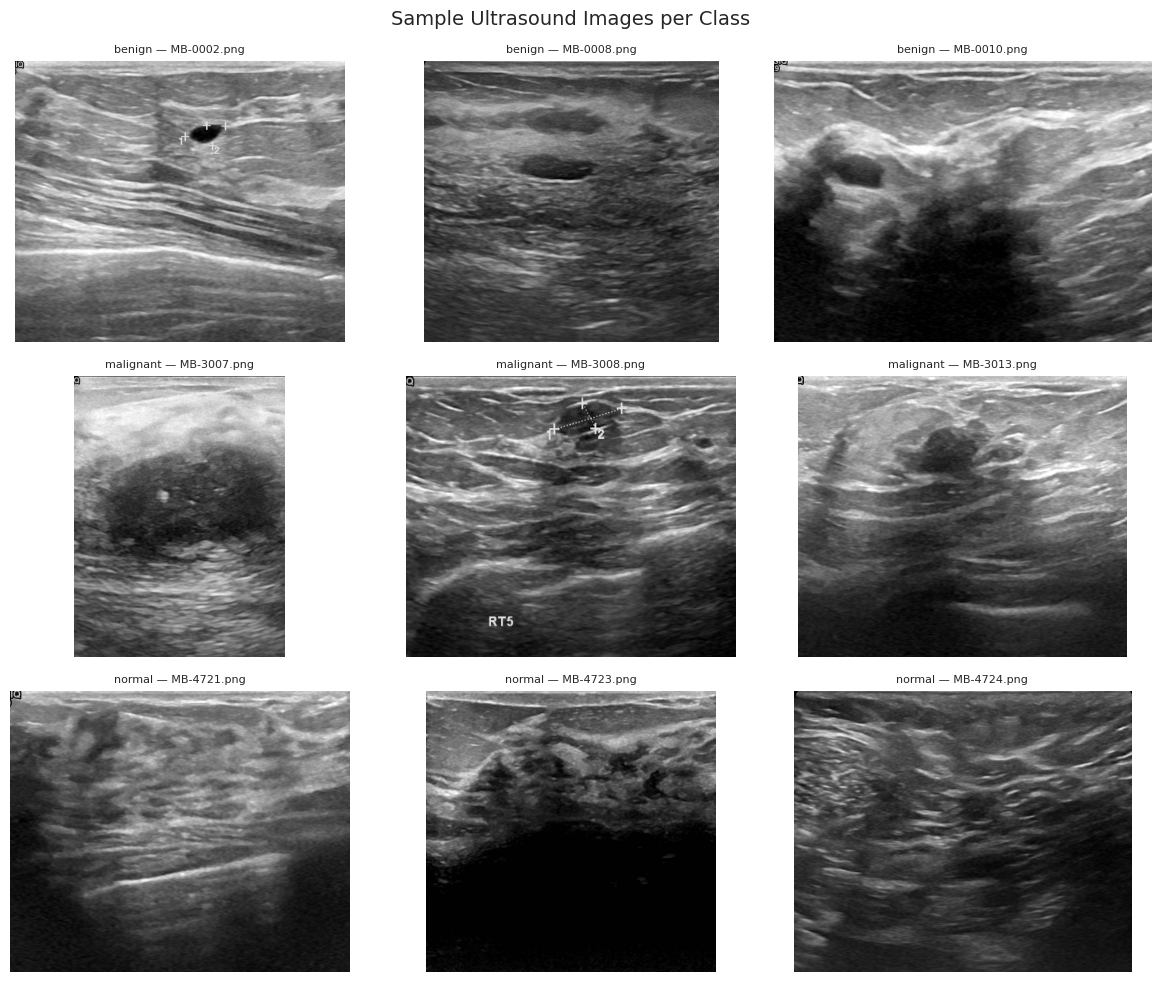

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Sample Ultrasound Images per Class', fontsize=14)

for row, cls in enumerate(CLASSES):
    samples = iter_class_images(DATA_ROOT, cls)[:3]
    for col, p in enumerate(samples):
        axes[row][col].imshow(Image.open(p), cmap='gray')
        axes[row][col].set_title(f'{cls} — {p.name}', fontsize=8)
        axes[row][col].axis('off')
    for col in range(len(samples), 3):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/sample_images.png', dpi=150)
plt.show()

## 1.4 — Mask Overlay Visualisation

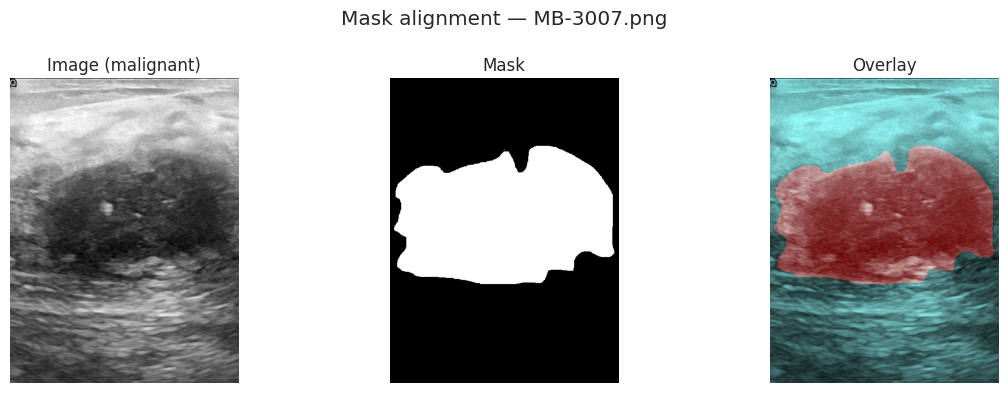

In [5]:
def mask_path_for_image(img_path: Path) -> Path | None:
    p = Path(img_path)
    m = p.parent.parent / 'masks' / p.name
    return m if m.exists() else None


examples = []
for cls in ('malignant', 'benign'):
    for p in iter_class_images(DATA_ROOT, cls)[:5]:
        m = mask_path_for_image(p)
        if m is not None:
            examples.append((p, m, cls))
            break

if not examples:
    print('No image/mask pairs found (check dataset layout).')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    img_p, mk_p, cls = examples[0]
    raw = np.array(Image.open(img_p).convert('RGB'))
    msk = np.array(Image.open(mk_p).convert('L'))
    msk = (msk > 127).astype(float)
    if msk.shape[:2] != raw.shape[:2]:
        msk = np.array(Image.fromarray((msk * 255).astype(np.uint8)).resize((raw.shape[1], raw.shape[0])))
        msk = (msk > 127).astype(float)
    overlay = raw.copy()
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] * 0.6 + msk * 255 * 0.4, 0, 255)
    axes[0].imshow(raw)
    axes[0].set_title(f'Image ({cls})')
    axes[1].imshow(msk, cmap='gray')
    axes[1].set_title('Mask')
    axes[2].imshow(overlay.astype(np.uint8))
    axes[2].set_title('Overlay')
    for ax in axes:
        ax.axis('off')
    plt.suptitle(f'Mask alignment — {img_p.name}')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures/mask_overlay_example.png', dpi=150)
    plt.show()

## 1.5 — Tabular / Clinical Data

In [6]:
df = build_aligned_manifest(DATA_ROOT)
print('Loaded: merged Kaggle tabular + image paths (647 patients with ultrasound)')
print('Shape:', df.shape)
print(df.dtypes.head(20))
print(df.head())


Loaded: merged Kaggle tabular + image paths (647 patients with ultrasound)
Shape: (647, 37)
Patient ID                            str
Age at Diagnosis                  float64
Type of Breast Surgery                str
Cohort                            float64
ER status measured by IHC             str
ER Status                             str
Neoplasm Histologic Grade         float64
HER2 status measured by SNP6          str
HER2 Status                           str
Tumor Other Histologic Subtype        str
Hormone Therapy                       str
Inferred Menopausal State             str
Primary Tumor Laterality              str
Lymph nodes examined positive     float64
Tumor Size                        float64
Tumor Stage                       float64
Mutation Count                    float64
Nottingham prognostic index       float64
Overall Survival (Months)         float64
Overall Survival Status               str
dtype: object
  Patient ID  Age at Diagnosis Type of Breast Surgery 

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.concat([missing, missing_pct], axis=1, keys=['count', '%'])
print(miss_df.head(25))
if len(miss_df) > 25:
    print('...')

                                count    %
Patient ID                          0  0.0
Age at Diagnosis                    0  0.0
Type of Breast Surgery              0  0.0
Cohort                              0  0.0
ER status measured by IHC           0  0.0
ER Status                           0  0.0
Neoplasm Histologic Grade           0  0.0
HER2 status measured by SNP6        0  0.0
HER2 Status                         0  0.0
Tumor Other Histologic Subtype      0  0.0
Hormone Therapy                     0  0.0
Inferred Menopausal State           0  0.0
Primary Tumor Laterality            0  0.0
Lymph nodes examined positive       0  0.0
Tumor Size                          0  0.0
Tumor Stage                         0  0.0
Mutation Count                      0  0.0
Nottingham prognostic index         0  0.0
Overall Survival (Months)           0  0.0
Overall Survival Status             0  0.0
Relapse Free Status (Months)        0  0.0
Relapse Free Status                 0  0.0
Sex        

class
benign       437
malignant    210
Name: count, dtype: int64


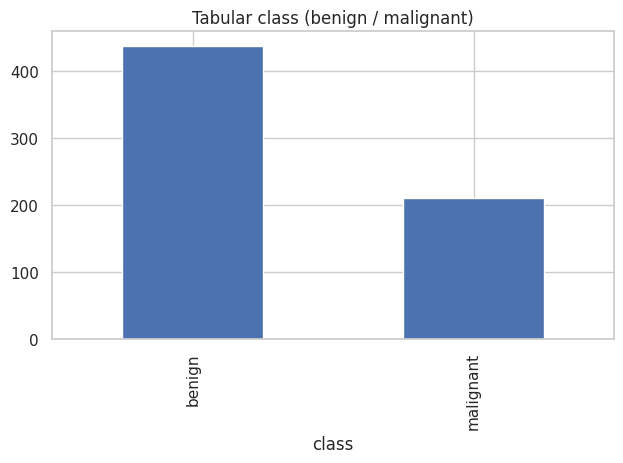

In [8]:
if USE_ALIGNED and 'class' in df.columns:
    vc = df['class'].value_counts()
    print(vc)
    vc.plot(kind='bar', title='Tabular class (benign / malignant)')
elif 'label' in df.columns:
    print(df['label'].value_counts())
    df['label'].value_counts().plot(kind='bar', title='Tabular Label Distribution')
elif 'Event' in df.columns:
    print(df['Event'].value_counts())
    df['Event'].astype(str).value_counts().plot(kind='bar', title='Event distribution')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/tabular_label_distribution.png', dpi=150)
plt.show()

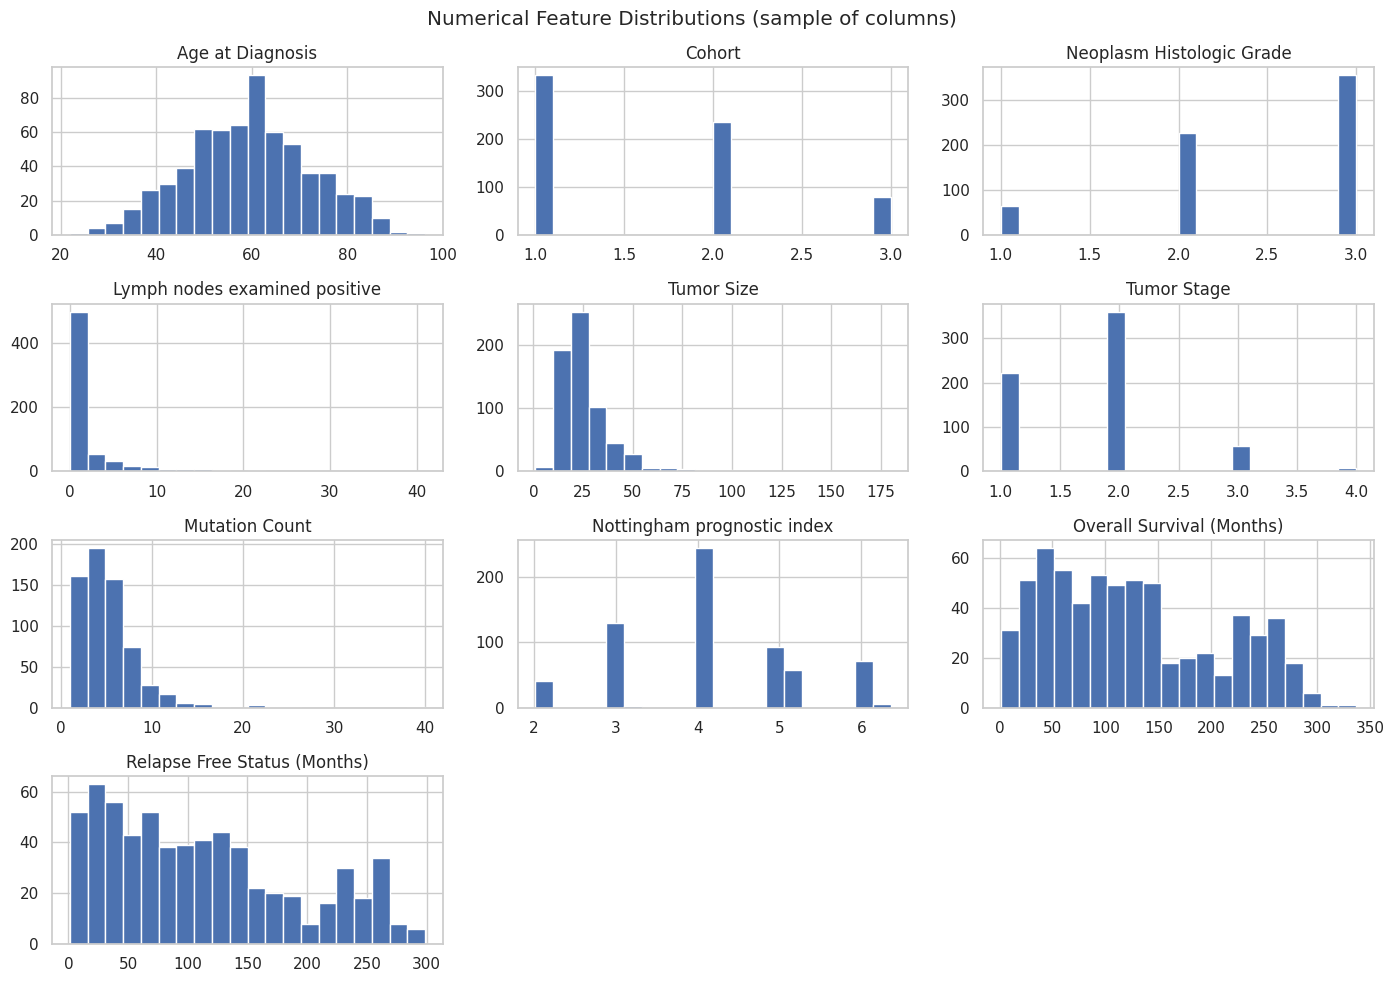

In [9]:
drop_vis = {'patient_id', 'label_enc', 'image_path', 'split', 'Patient ID'}
num_candidates = [c for c in df.select_dtypes(include='number').columns if c not in drop_vis]
numerical_cols = num_candidates[:12]
if numerical_cols:
    df[numerical_cols].hist(figsize=(14, 10), bins=20)
    plt.suptitle('Numerical Feature Distributions (sample of columns)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures/feature_distributions.png', dpi=150)
    plt.show()
else:
    print('No numeric columns to plot.')

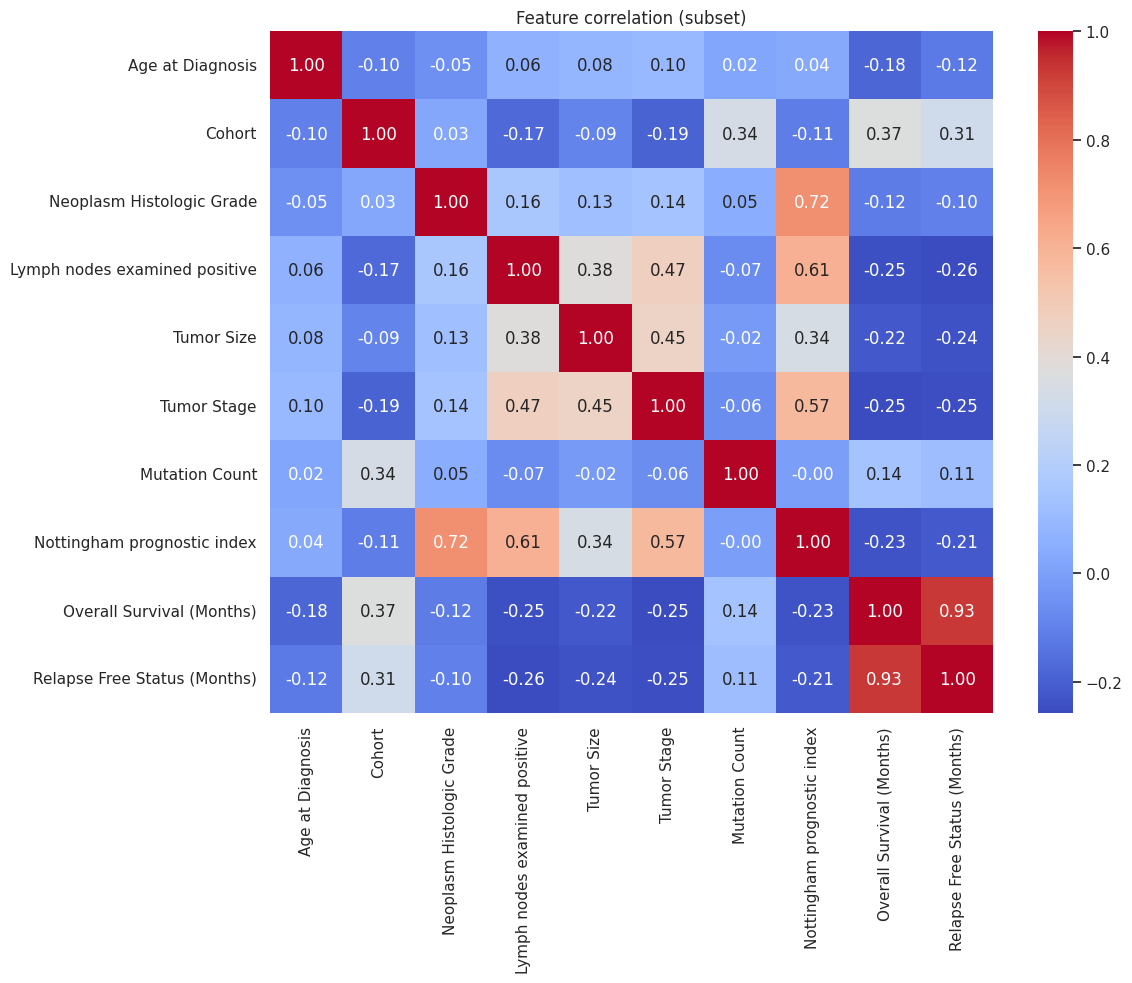

In [10]:
hm_cols = num_candidates[:15]
if len(hm_cols) >= 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[hm_cols].corr(), annot=len(hm_cols) <= 10, fmt='.2f', cmap='coolwarm', ax=ax)
    ax.set_title('Feature correlation (subset)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures/correlation_heatmap.png', dpi=150)
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')

## 1.6 — Summary

- **Images:** Per-class counts are in section 1.1. Paths support both `data/raw/<class>/images/` and nested `data/raw/dataset/dataset*/<class>/images/`.
- **Tabular:** With the Kaggle extract, section 1.5 uses the merged clinical + molecular table (647 patients with matching ultrasound). Section 1.5 uses the merged clinical + molecular table (647 patients with matching ultrasound).
- **Masks:** Example overlay saved as `results/figures/mask_overlay_example.png` when mask files exist.
- **Imbalance:** Benign cases typically exceed malignant; Tasks 2–3 use class weighting (`CrossEntropyLoss` weights, `scale_pos_weight` in XGBoost).